<a href="https://colab.research.google.com/github/OlenaM32/CapstoneProject/blob/main/Dog_Parks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Panda

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
# Load the dataset
from google.colab import files
uploaded = files.upload()


Saving Dog_Runs_20260421.csv to Dog_Runs_20260421.csv


In [4]:
import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['Dog_Runs_20260421.csv']))


Dog Runs is now uploaded

A Cleaner Class

In [5]:
class DogRunData:
  def __init__(self, dataframe):
    self.df = dataframe

  def get_dataframe(self):
    return self.df.info()

    project_data = DogRunData(df)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   OBJECTID         92 non-null     object
 1   SYSTEM           89 non-null     object
 2   the_geom         92 non-null     object
 3   GISPROPNUM       89 non-null     object
 4   DEPARTMENT       92 non-null     object
 5   PARENTID         89 non-null     object
 6   COMMUNITYBOARD   81 non-null     object
 7   COUNCILDISTRICT  82 non-null     object
 8   PRECINCT         84 non-null     object
 9   ZIPCODE          78 non-null     object
 10  BOROUGH          92 non-null     object
 11  DOG_AREA_TYPE    92 non-null     object
 12  NAME             92 non-null     object
 13  SEATING          22 non-null     object
 14  SURFACE          19 non-null     object
 15  FEATURESTATUS    92 non-null     object
dtypes: object(16)
memory usage: 11.6+ KB


Data Transformation

In [8]:
def expand_borough_names(code):
    names = {
        'M': 'Manhattan',
        'B': 'Brooklyn',
        'X': 'Bronx',
        'Q': 'Queens',
        'R': 'Staten Island'
    }
    return names.get(code, "Unknown")

Transformation 1

In [9]:
df['borough_name'] = df['BOROUGH'].apply(expand_borough_names)

In [10]:
df['seating_status'] = df['SEATING'].fillna('Unknown')

Statistical Analysis

In [11]:
#Create a table
contingency_table = pd.crosstab(df['borough_name'], df['SEATING'])

#run the test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"P-value for SEATING vs BOROUGH: {p:.4f}")

P-value for SEATING vs BOROUGH: 0.3179


Visualization

/tmp/ipykernel_10095/3217409555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='borough_name', palette='magma', order=df['borough_name'].value_counts().index)


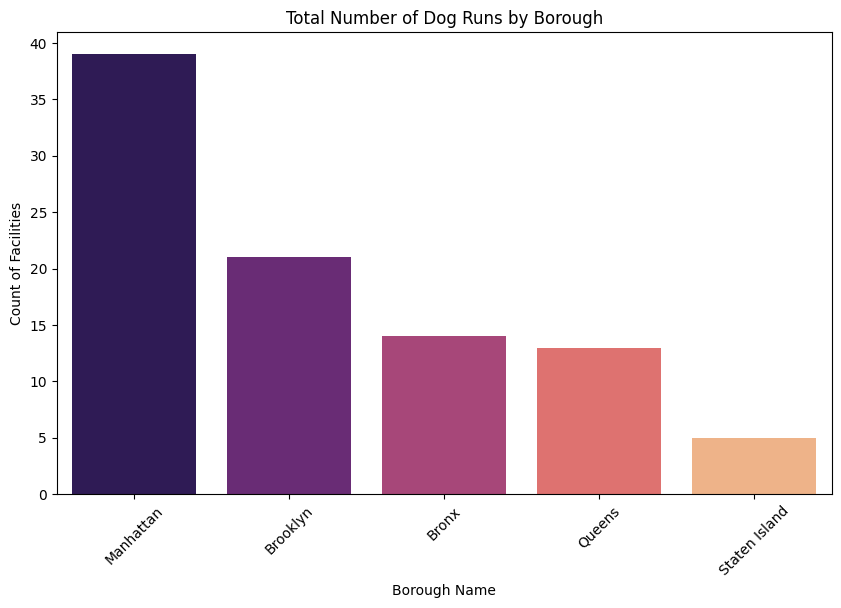

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='borough_name', palette='magma', order=df['borough_name'].value_counts().index)

plt.title('Total Number of Dog Runs by Borough')
plt.xlabel('Borough Name')
plt.ylabel('Count of Facilities')
plt.xticks(rotation=45)
plt.show()